# O6 Multimodal — fixed leaf sizes, 20D / 20 instances

Fixed leaf sizes 1–5, dimension 20, 20 instances, 1,500 trials, and `min_samples_split=1`.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
if HERE.name != "02_20d_20_instances":
    HERE = Path("/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o6_multi_modal/leaf_policies/02_20d_20_instances")
OUTPUT_DIRECTORY = HERE / "smac_output"
DIMENSION = 20
N_INSTANCES = 20
N_TRIALS = 1500
PROBLEM_SEED = 52
SEEDS = tuple(range(5))
LEAF_SIZES = (1, 2, 3, 4, 5)
POLICIES = tuple(f"fixed_leaf_{leaf}" for leaf in LEAF_SIZES)
CHECKPOINTS = tuple(range(100, N_TRIALS + 1, 100))
LABELS = {f"fixed_leaf_{leaf}": f"leaf = {leaf}" for leaf in LEAF_SIZES}
COLORS = dict(zip(POLICIES, ("C0", "C1", "C2", "C3", "C4")))

In [2]:
def load(policy):
    runs = {}
    for path in (OUTPUT_DIRECTORY / policy).rglob("trajectory.json"):
        result = json.loads(path.read_text())
        if result["smac_seed"] in SEEDS and result["n_trials"] == N_TRIALS and result["problem_seed"] == PROBLEM_SEED:
            runs[result["smac_seed"]] = result
    missing = sorted(set(SEEDS) - set(runs))
    if missing:
        raise FileNotFoundError(f"Missing {policy}: seeds={missing}")
    return runs


results = {policy: load(policy) for policy in POLICIES}
for policy, runs in results.items():
    leaf = int(policy.rsplit("_", 1)[1])
    for result in runs.values():
        assert result["problem"] == "O6-Multimodal"
        assert result["dimension"] == DIMENSION
        assert result["n_instances"] == N_INSTANCES
        assert len(result["instance_map"]) == N_INSTANCES
        assert result["problem_seed"] == PROBLEM_SEED
        assert result["pythonhashseed"] == "12345"
        assert result["initial_design"] == "random"
        assert result["n_initial_configs"] == 10
        assert result["initial_design_seed"] == result["smac_seed"]
        assert result["min_samples_split"] == 1
        assert result["min_samples_leaf"] == leaf
        assert result["initial_min_samples_leaf"] == leaf
        assert len(result["iteration"]) == N_TRIALS
        assert len(result["best_regret"]) == N_TRIALS
print(f"Loaded {sum(map(len, results.values()))}/25 validated trajectories.")

Loaded 25/25 validated trajectories.


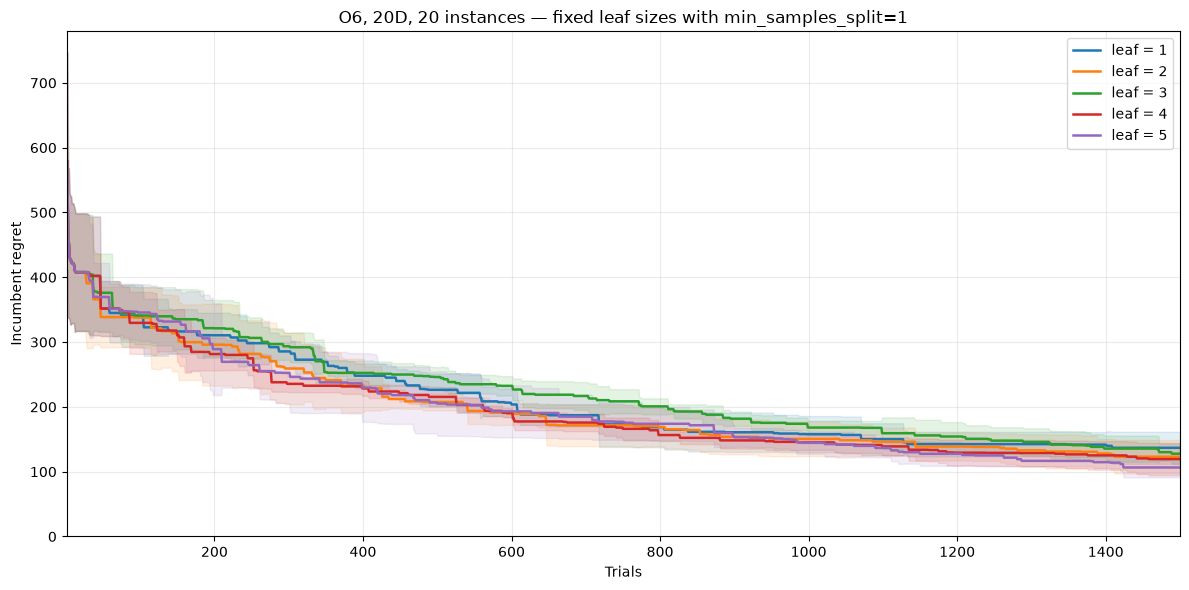

In [3]:
rows = [
    {"policy": policy, "seed": seed, "iteration": iteration, "best_regret": regret}
    for policy, runs in results.items()
    for seed, result in runs.items()
    for iteration, regret in zip(result["iteration"], result["best_regret"])
]
trajectories = pd.DataFrame(rows)
summary = trajectories.groupby(["policy", "iteration"])["best_regret"].agg(["mean", "std", "count"]).reset_index()
summary["ci95"] = 1.96 * summary["std"] / np.sqrt(summary["count"])

fig, ax = plt.subplots(figsize=(12, 6))
for policy in POLICIES:
    data = summary[summary.policy == policy]
    ax.plot(data.iteration, data["mean"], label=LABELS[policy], color=COLORS[policy], linewidth=1.8)
    ax.fill_between(data.iteration, np.maximum(0, data["mean"] - data.ci95), data["mean"] + data.ci95, color=COLORS[policy], alpha=.12)
ax.set(title="O6, 20D, 20 instances — fixed leaf sizes with min_samples_split=1", xlabel="Trials", ylabel="Incumbent regret", xlim=(1, N_TRIALS), ylim=(0, None))
ax.grid(alpha=.25)
ax.legend()
plt.tight_layout()
plt.show()

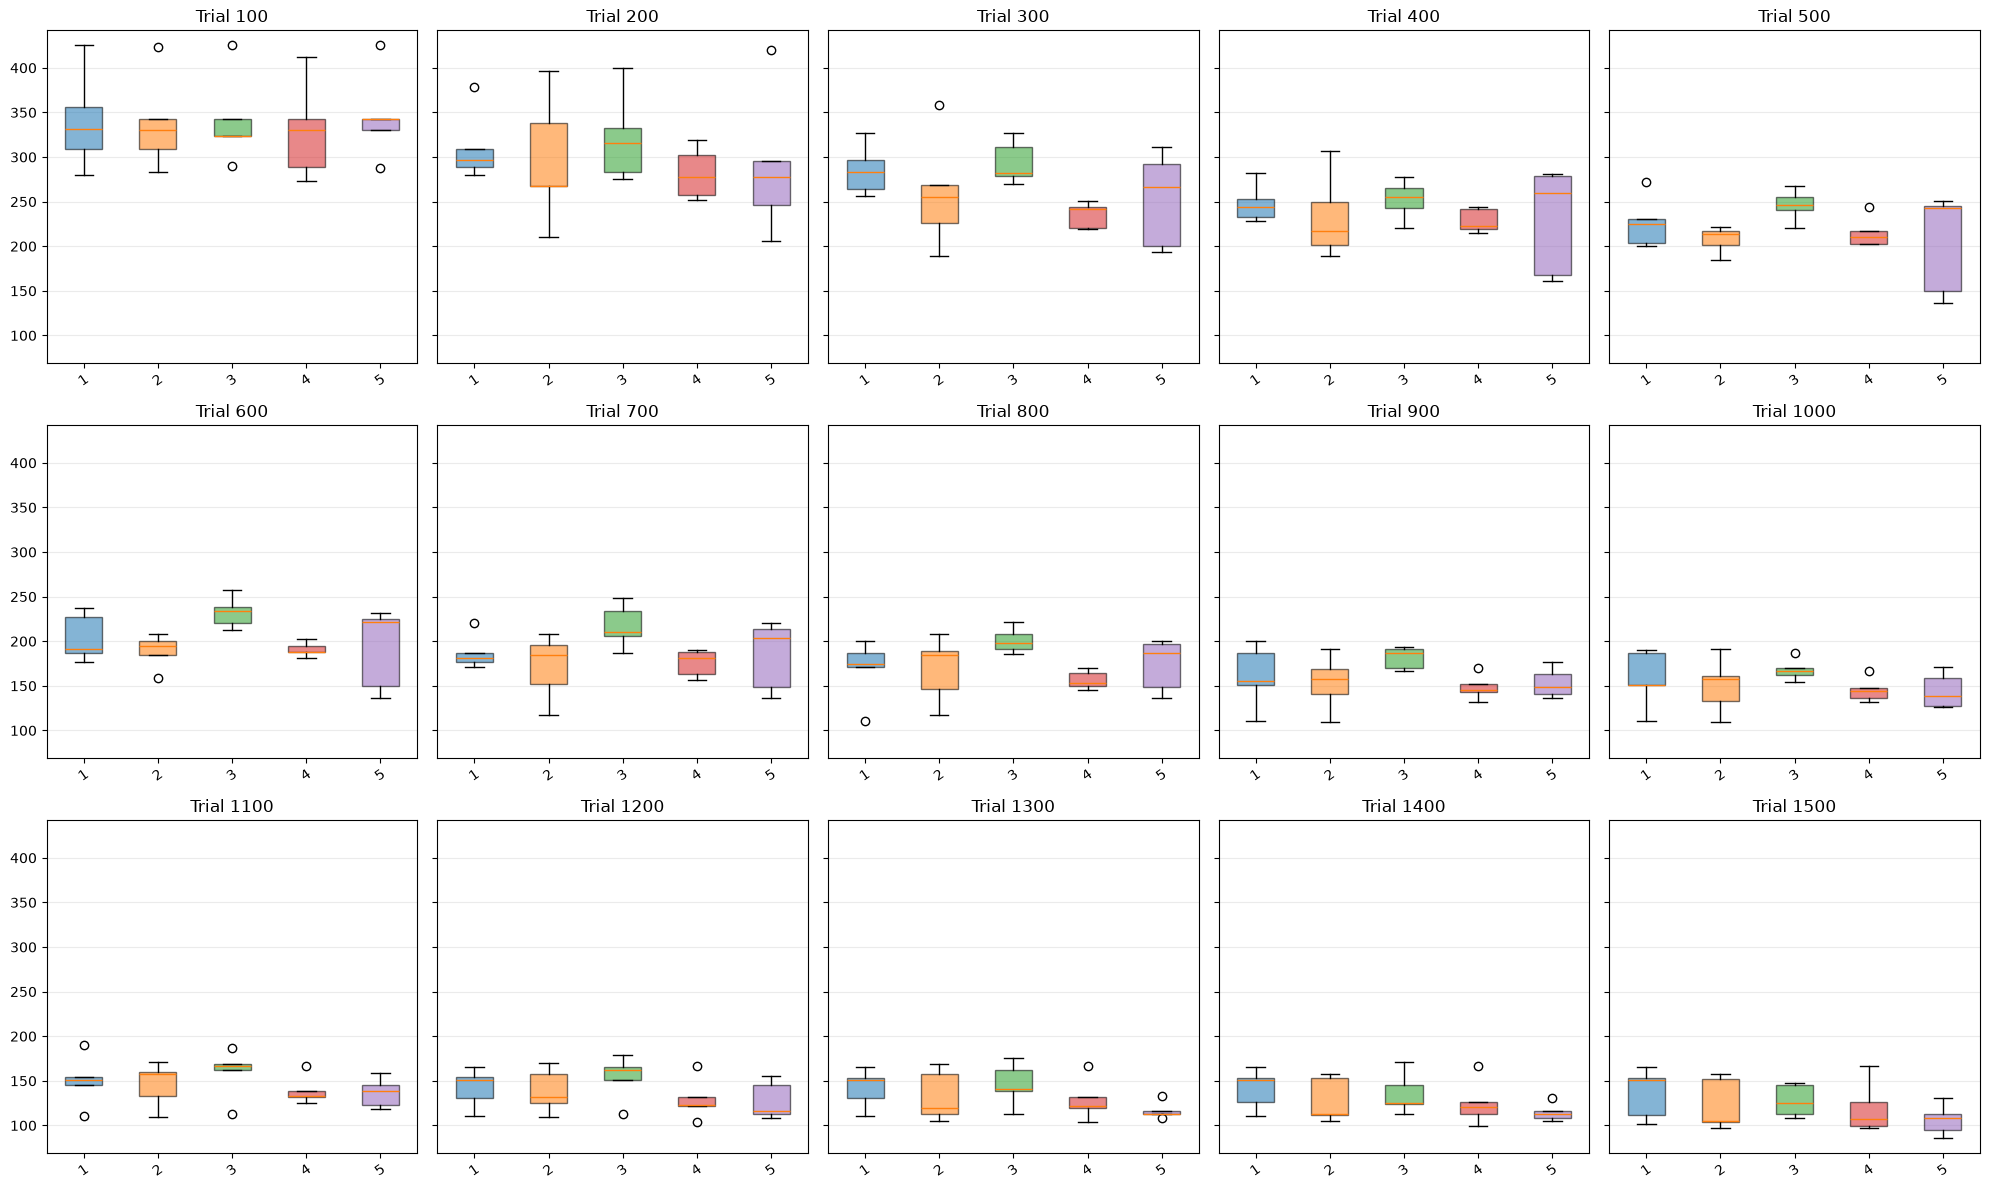

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)
for ax, checkpoint in zip(axes.flat, CHECKPOINTS):
    values = [[results[policy][seed]["best_regret"][checkpoint - 1] for seed in SEEDS] for policy in POLICIES]
    boxes = ax.boxplot(values, patch_artist=True, tick_labels=[str(leaf) for leaf in LEAF_SIZES])
    for box, policy in zip(boxes["boxes"], POLICIES):
        box.set(facecolor=COLORS[policy], alpha=.55)
    ax.set_title(f"Trial {checkpoint}")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=.25)
plt.tight_layout()
plt.show()

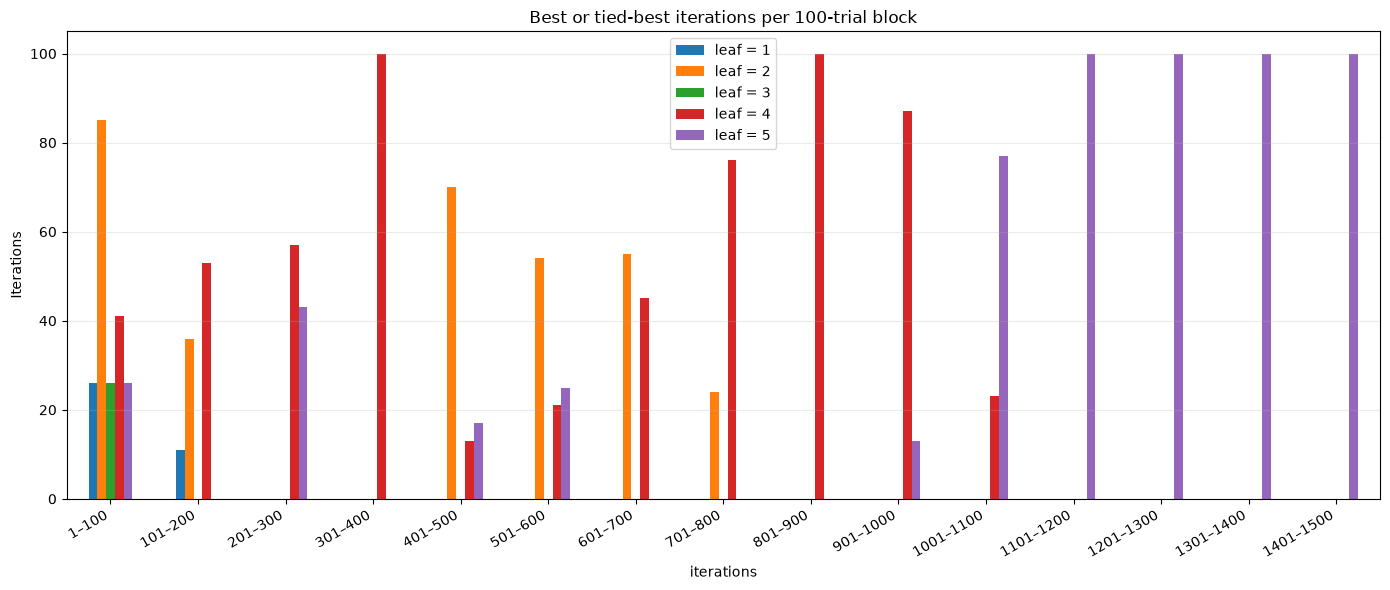

,iterations,superior policy,leaf = 1,leaf = 2,leaf = 3,leaf = 4,leaf = 5
0,1–100,leaf = 2,26,85,26,41,26
1,101–200,leaf = 4,11,36,0,53,0
2,201–300,leaf = 4,0,0,0,57,43
3,301–400,leaf = 4,0,0,0,100,0
4,401–500,leaf = 2,0,70,0,13,17
5,501–600,leaf = 2,0,54,0,21,25
6,601–700,leaf = 2,0,55,0,45,0
7,701–800,leaf = 4,0,24,0,76,0
8,801–900,leaf = 4,0,0,0,100,0
9,901–1000,leaf = 4,0,0,0,87,13


In [5]:
mean_regret = trajectories.pivot_table(index="iteration", columns="policy", values="best_regret", aggfunc="mean").reindex(columns=POLICIES)
best = mean_regret.min(axis=1)
wins = pd.DataFrame({policy: np.isclose(mean_regret[policy], best, rtol=1e-12, atol=1e-9) for policy in POLICIES}, index=mean_regret.index)
block_rows = []
for end in CHECKPOINTS:
    counts = wins.loc[end - 99:end].sum()
    maximum = int(counts.max())
    row = {"iterations": f"{end - 99}–{end}", "superior policy": ", ".join(LABELS[policy] for policy in POLICIES if counts[policy] == maximum)}
    row.update({LABELS[policy]: int(counts[policy]) for policy in POLICIES})
    block_rows.append(row)
block_superiority = pd.DataFrame(block_rows)
ax = block_superiority.set_index("iterations")[[LABELS[policy] for policy in POLICIES]].plot(kind="bar", figsize=(14, 6), color=[COLORS[policy] for policy in POLICIES])
ax.set(title="Best or tied-best iterations per 100-trial block", ylabel="Iterations", ylim=(0, 105))
ax.grid(axis="y", alpha=.25)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(block_superiority)

In [6]:
run_rows = []
for policy, runs in results.items():
    for seed, result in runs.items():
        regret = np.asarray(result["best_regret"], dtype=float)
        run_rows.append({"policy": LABELS[policy], "seed": seed, "final_regret": regret[-1], "mean_incumbent_regret": regret.mean()})
run_metrics = pd.DataFrame(run_rows)
metric_summary = run_metrics.groupby("policy")[["final_regret", "mean_incumbent_regret"]].agg(["mean", "std", "median", "min", "max"]).sort_values(("final_regret", "mean"))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(metric_summary)
    display(run_metrics.sort_values(["seed", "final_regret"]))

final_regret                                                 \
                 mean        std      median         min         max   
policy                                                                 
leaf = 5   106.482559  17.309704  107.917967   86.333412  131.254437   
leaf = 4   119.434237  28.592595  107.185152   97.643796  166.236419   
leaf = 2   123.094359  29.434315  104.809699   96.934140  157.985263   
leaf = 3   127.751191  17.812532  125.464271  108.657959  147.151137   
leaf = 1   136.880907  28.211215  151.331213  101.851232  165.730615   

         mean_incumbent_regret                                                 
                          mean        std      median         min         max  
policy                                                                         
leaf = 5            195.428651  31.299646  213.458644  157.432944  223.492128  
leaf = 4            193.669483   6.791343  191.651312  185.818422  201.690385  
leaf = 2            197.676896  26.382960  195.927121  157.013016  225.708275  
leaf = 3            221.473949  13.813370  224.679550  201.839410  236.853309  
leaf = 1            208.316460  13.673391  209.833450  192.922299  228.919784

,policy,seed,final_regret,mean_incumbent_regret
19,leaf = 4,0,99.389169,189.458761
9,leaf = 2,0,104.809699,157.013016
24,leaf = 5,0,112.354568,213.458644
14,leaf = 3,0,147.151137,230.072468
4,leaf = 1,0,153.734976,210.496283
23,leaf = 5,1,94.552412,223.492128
3,leaf = 1,1,101.851232,209.833450
8,leaf = 2,1,103.542194,225.708275
13,leaf = 3,1,112.600581,236.853309
18,leaf = 4,1,126.716651,199.728538


In [7]:
checkpoint_table = trajectories[trajectories.iteration.isin(CHECKPOINTS)].groupby(["iteration", "policy"])["best_regret"].agg(["mean", "std", "min", "median", "max"])
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(checkpoint_table)

mean        std         min      median  \
iteration policy                                                        
100       fixed_leaf_1  340.175931  55.197642  279.738742  331.460081   
          fixed_leaf_2  337.797184  53.024835  283.493127  329.994861   
          fixed_leaf_3  340.985255  50.829436  289.511008  323.697176   
          fixed_leaf_4  329.649243  54.494069  273.033367  330.663392   
          fixed_leaf_5  345.658895  49.819489  287.688939  342.113426   
200       fixed_leaf_1  310.494835  39.704616  279.738742  296.163397   
          fixed_leaf_2  295.973704  71.938722  210.363760  268.071096   
          fixed_leaf_3  321.231312  49.786123  275.013570  316.231802   
          fixed_leaf_4  281.521619  28.842270  251.448255  277.523812   
          fixed_leaf_5  289.053214  80.761009  205.634947  277.264447   
300       fixed_leaf_1  285.585283  28.083472  256.590366  283.310931   
          fixed_leaf_2  259.183892  63.035665  189.165906  254.864134   
          fixed_leaf_3  293.552068  23.937361  269.946875  281.908712   
          fixed_leaf_4  235.533605  14.423718  219.739549  241.884088   
          fixed_leaf_5  252.512785  53.417233  193.531028  265.893973   
400       fixed_leaf_1  248.115918  21.509804  228.571440  243.645312   
          fixed_leaf_2  232.905217  47.260853  189.165906  216.658386   
          fixed_leaf_3  252.420445  21.794004  220.852931  255.373937   
          fixed_leaf_4  228.666974  13.334087  215.394290  222.197420   
          fixed_leaf_5  229.794831  60.332926  161.529902  259.594455   
500       fixed_leaf_1  226.355887  28.528686  200.413299  224.567025   
          fixed_leaf_2  207.582459  14.890338  184.378829  213.170560   
          fixed_leaf_3  246.074213  17.337596  220.852931  246.342371   
          fixed_leaf_4  215.413272  17.149425  202.527817  210.814474   
          fixed_leaf_5  205.101698  56.759144  136.441264  243.009807   
600       fixed_leaf_1  203.699136  26.591924  176.860587  191.340427   
          fixed_leaf_2  189.267235  19.355841  158.267491  194.981311   
          fixed_leaf_3  232.466382  17.081823  212.694071  233.602072   
          fixed_leaf_4  190.881074   8.189715  181.412676  187.714932   
          fixed_leaf_5  193.037715  45.878640  136.441264  221.425228   
700       fixed_leaf_1  187.111878  19.551992  170.844614  181.693984   
          fixed_leaf_2  171.469945  36.635975  117.655281  184.307005   
          fixed_leaf_3  216.841525  24.505048  186.542252  209.883937   
          fixed_leaf_4  175.790288  15.192451  156.236295  181.412676   
          fixed_leaf_5  184.812211  39.015418  136.441264  204.177064   
800       fixed_leaf_1  168.668603  34.182672  111.038366  174.882876   
          fixed_leaf_2  168.973955  36.413779  117.655281  184.307005   
          fixed_leaf_3  200.805374  14.075757  185.617544  197.779741   
          fixed_leaf_4  156.578799  10.470463  144.878815  153.560950   
          fixed_leaf_5  173.932855  29.552485  136.441264  186.964524   
900       fixed_leaf_1  160.862394  34.653097  111.038366  155.365233   
          fixed_leaf_2  153.830590  30.776275  109.862455  157.985263   
          fixed_leaf_3  181.774087  12.461771  166.793800  186.632714   
          fixed_leaf_4  148.347544  14.333628  131.645990  144.878815   
          fixed_leaf_5  153.076521  16.642336  136.441264  148.288229   
1000      fixed_leaf_1  157.803524  32.063996  111.038366  151.331213   
          fixed_leaf_2  150.616330  30.798759  109.862455  157.985263   
          fixed_leaf_3  168.072309  12.190210  154.372633  166.793800   
          fixed_leaf_4  145.203303  13.287461  131.645990  144.143478   
          fixed_leaf_5  144.514628  19.573442  126.753961  138.117935   
1100      fixed_leaf_1  150.200150  28.011085  111.038366  151.331213   
          fixed_leaf_2  146.396597  24.733929  109.862455  157.985263   
          fixed_leaf_3  159.350441  27.834341  112.600581  166.793800   
          fixed